# SleepSense — Feature Engineering & EDA Validation

This notebook validates the feature store pipeline, explores the relationships between passive sensing/survey features and sleep quality ratings, and prepares the dataset for machine learning models.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# Load the merged preprocessed dataset
dataset_path = "../data/preprocessed/merged/dataset.parquet"
if not os.path.exists(dataset_path):
    dataset_path = "data/preprocessed/merged/dataset.parquet"

df = pd.read_parquet(dataset_path)
print(f"Dataset shape: {df.shape}")
print(f"Columns: {list(df.columns)}")

Dataset shape: (1321, 42)
Columns: ['user_id', 'date', 'unlock_count_late_night', 'unlock_count_evening', 'unlock_count_daytime', 'first_unlock_hour', 'last_unlock_hour', 'avg_session_duration_min', 'screen_sessions_count', 'stationary_ratio', 'walking_minutes', 'running_minutes', 'exercise_detected', 'peak_activity_hour', 'activity_bout_count', 'app_social_min', 'app_entertainment_evening_min', 'app_late_night_min', 'last_active_app_hour', 'app_diversity_count', 'app_study_sessions', 'silence_ratio', 'conversation_ratio', 'social_audio_evening', 'location_entropy', 'mobility_radius', 'unique_locations_count', 'stress_level', 'mood_happy', 'mood_tired', 'social_contacts', 'exercise_self_report', 'study_hours_today', 'day_of_week', 'is_weekend', 'psqi_pre_score', 'personality_extraversion', 'personality_agreeableness', 'personality_conscientiousness', 'personality_neuroticism', 'personality_openness', 'sleep_score']


## 1. Class Balance: Target Label Distribution

Let's inspect the target variable `sleep_score`.

Fairly bad (1): 505 samples (38.2%)
Fairly good (2): 578 samples (43.8%)
Very good (3): 238 samples (18.0%)


C:\Users\HP\AppData\Local\Temp\ipykernel_36320\783137544.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='sleep_label', order=['Very bad', 'Fairly bad', 'Fairly good', 'Very good'], palette='viridis')


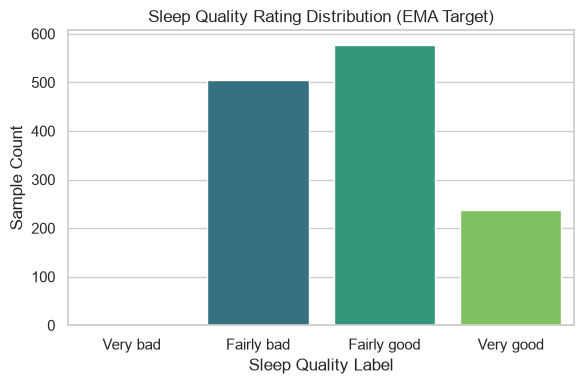

In [2]:
label_map = {3: 'Very good', 2: 'Fairly good', 1: 'Fairly bad', 0: 'Very bad'}
df['sleep_label'] = df['sleep_score'].map(label_map)

target_counts = df['sleep_score'].value_counts().sort_index()
target_pct = df['sleep_score'].value_counts(normalize=True).sort_index() * 100

for val, count in target_counts.items():
    print(f"{label_map[val]} ({val}): {count} samples ({target_pct[val]:.1f}%)")

# Plot target distribution
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='sleep_label', order=['Very bad', 'Fairly bad', 'Fairly good', 'Very good'], palette='viridis')
plt.title("Sleep Quality Rating Distribution (EMA Target)")
plt.xlabel("Sleep Quality Label")
plt.ylabel("Sample Count")
plt.tight_layout()
os.makedirs('../implementation', exist_ok=True)
os.makedirs('implementation', exist_ok=True)
try:
    plt.savefig('../implementation/eda_class_distribution.png', dpi=150)
except Exception:
    plt.savefig('implementation/eda_class_distribution.png', dpi=150)
plt.show()

## 2. Missing Value Analysis

Let's examine how much missing data is present in each column. Some modalities may have higher missingness due to phone power-offs or sensors being disabled.

Columns with missing values:
                      Missing Count  Percentage (%)
mood_happy                     1147       86.828160
social_contacts                 479       36.260409
stress_level                    352       26.646480
first_unlock_hour                66        4.996215
last_unlock_hour                 66        4.996215
peak_activity_hour               48        3.633611
last_active_app_hour             25        1.892506


C:\Users\HP\AppData\Local\Temp\ipykernel_36320\1812069662.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=missing_df.index, y=missing_df['Percentage (%)'], palette='magma')


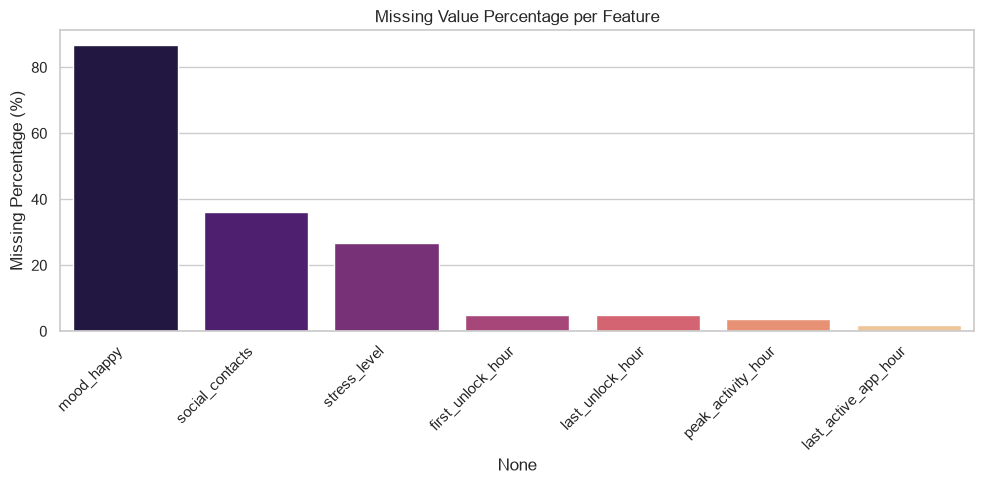

In [3]:
missing_counts = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing_counts, 'Percentage (%)': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values(by='Percentage (%)', ascending=False)

if missing_df.empty:
    print("No missing values found in the dataset! All features are complete.")
else:
    print("Columns with missing values:")
    print(missing_df)

    # Plot missingness
    plt.figure(figsize=(10, 5))
    sns.barplot(x=missing_df.index, y=missing_df['Percentage (%)'], palette='magma')
    plt.xticks(rotation=45, ha='right')
    plt.title("Missing Value Percentage per Feature")
    plt.ylabel("Missing Percentage (%)")
    plt.tight_layout()
    try:
        plt.savefig('../implementation/eda_missing_values.png', dpi=150)
    except Exception:
        plt.savefig('implementation/eda_missing_values.png', dpi=150)
    plt.show()

## 3. Feature Correlation with Sleep Quality Target

Let's look at which daytime behavioral signals are most strongly correlated with sleep quality.

Top 10 negative correlations with sleep quality:
silence_ratio                   -0.118379
mood_happy                      -0.103388
stationary_ratio                -0.087594
peak_activity_hour              -0.074587
is_weekend                      -0.063457
unlock_count_evening            -0.035379
last_unlock_hour                -0.032203
app_entertainment_evening_min   -0.030180
app_study_sessions              -0.026059
day_of_week                     -0.022295
Name: sleep_score, dtype: float64

Top 10 positive correlations with sleep quality:
activity_bout_count       0.084293
study_hours_today         0.099355
psqi_pre_score            0.110857
conversation_ratio        0.121825
walking_minutes           0.124878
exercise_detected         0.127927
unique_locations_count    0.129163
location_entropy          0.139625
social_contacts           0.141904
sleep_score               1.000000
Name: sleep_score, dtype: float64


C:\Users\HP\AppData\Local\Temp\ipykernel_36320\839230609.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_corr_features.values, y=top_corr_features.index, palette='coolwarm')


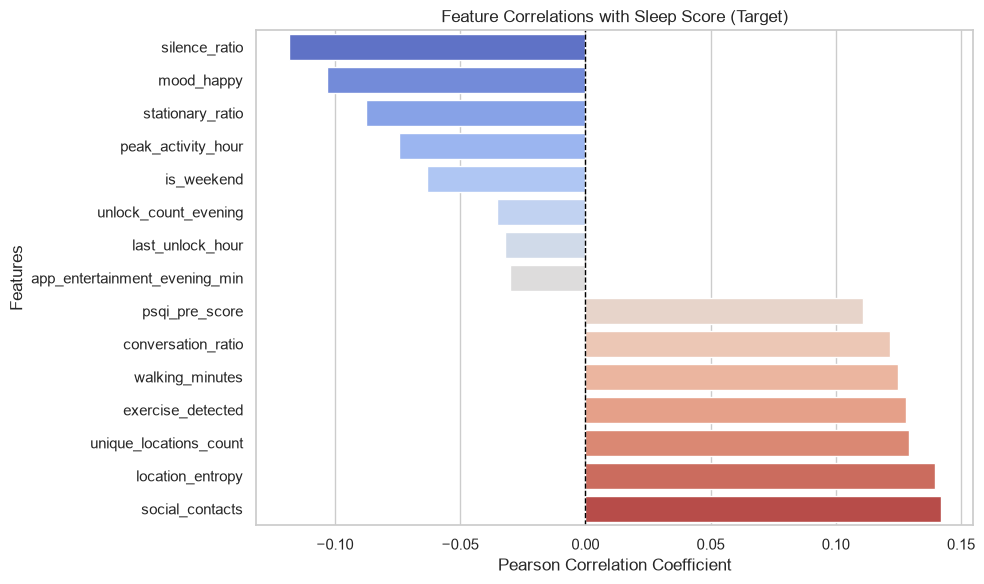

In [4]:
exclude_cols = ['user_id', 'date', 'sleep_label']
numeric_cols = [c for c in df.columns if c not in exclude_cols]

correlations = df[numeric_cols].corr()['sleep_score'].sort_values()
print("Top 10 negative correlations with sleep quality:")
print(correlations.head(10))
print("\nTop 10 positive correlations with sleep quality:")
print(correlations.tail(10))

# Plot top correlations
top_corr_features = pd.concat([correlations.head(8), correlations.tail(8)]).drop('sleep_score', errors='ignore').sort_values()
plt.figure(figsize=(10, 6))
sns.barplot(x=top_corr_features.values, y=top_corr_features.index, palette='coolwarm')
plt.title("Feature Correlations with Sleep Score (Target)")
plt.xlabel("Pearson Correlation Coefficient")
plt.ylabel("Features")
plt.axvline(x=0, color='black', linestyle='--', linewidth=1)
plt.tight_layout()
try:
    plt.savefig('../implementation/eda_correlations.png', dpi=150)
except Exception:
    plt.savefig('implementation/eda_correlations.png', dpi=150)
plt.show()

## 4. Key Behavioral Distributions Grouped by Sleep Quality

Let's check the distributions of some highly relevant predictors across sleep quality categories:
- Phone unlocks at late night (`unlock_count_late_night`)
- Stationary time ratio (`stationary_ratio`)
- Evening entertainment app use (`app_entertainment_evening_min`)
- Stress levels (`stress_level`)

C:\Users\HP\AppData\Local\Temp\ipykernel_36320\1822628532.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\HP\AppData\Local\Temp\ipykernel_36320\1822628532.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\HP\AppData\Local\Temp\ipykernel_36320\1822628532.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


C:\Users\HP\AppData\Local\Temp\ipykernel_36320\1822628532.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


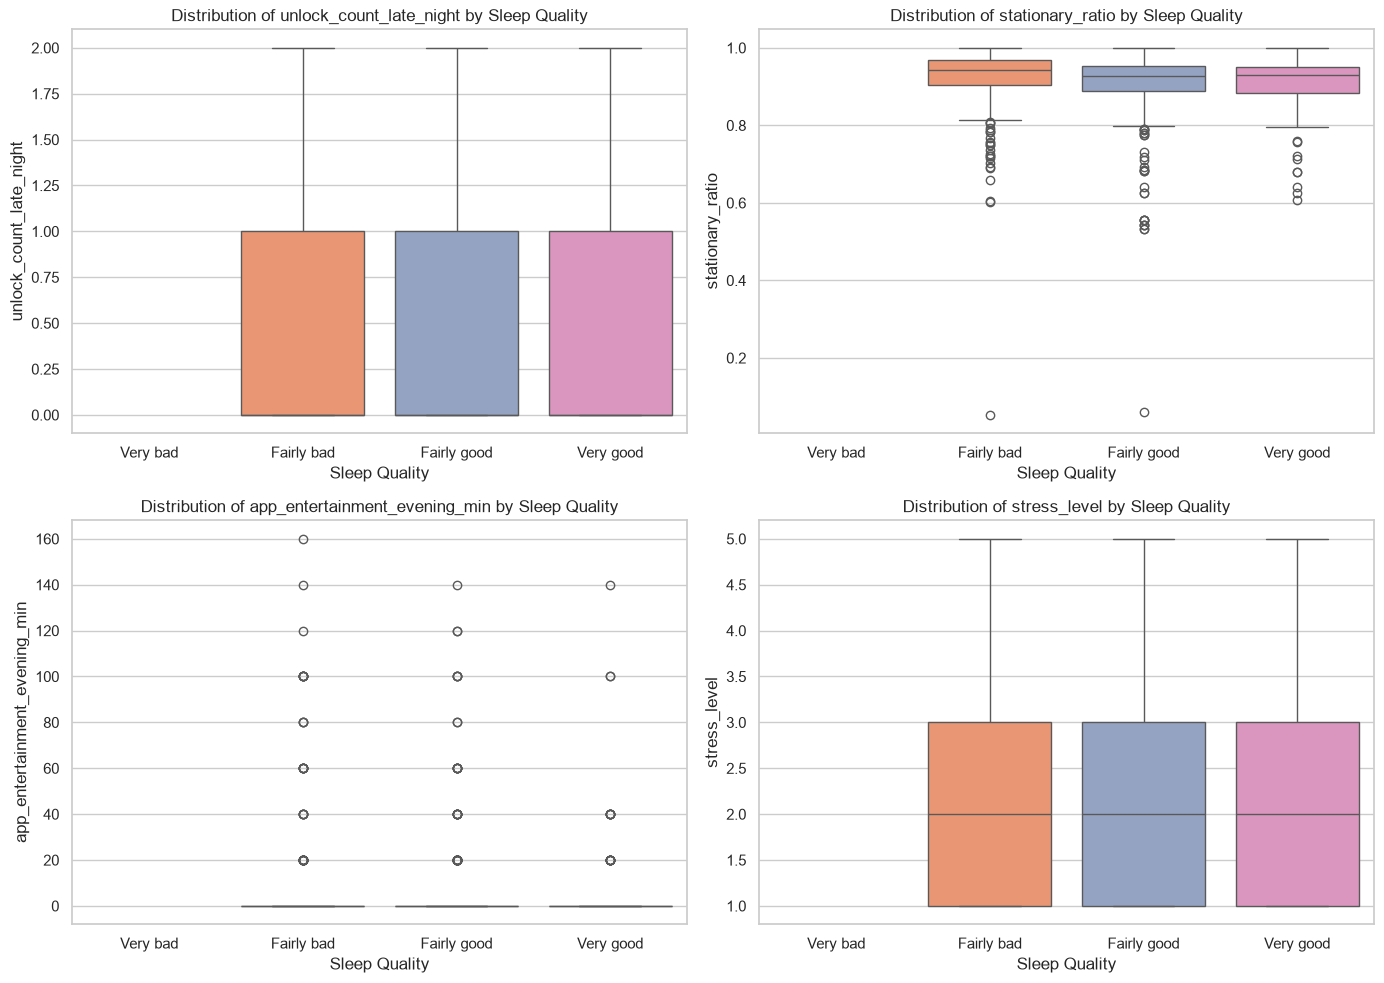

In [5]:
features_to_plot = [
    'unlock_count_late_night',
    'stationary_ratio',
    'app_entertainment_evening_min',
    'stress_level'
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, feat in enumerate(features_to_plot):
    if feat in df.columns:
        sns.boxplot(
            data=df, 
            x='sleep_label', 
            y=feat, 
            ax=axes[idx],
            order=['Very bad', 'Fairly bad', 'Fairly good', 'Very good'],
            palette='Set2'
        )
        axes[idx].set_title(f"Distribution of {feat} by Sleep Quality")
        axes[idx].set_xlabel("Sleep Quality")
        axes[idx].set_ylabel(feat)

plt.tight_layout()
try:
    plt.savefig('../implementation/eda_behavior_distributions.png', dpi=150)
except Exception:
    plt.savefig('implementation/eda_behavior_distributions.png', dpi=150)
plt.show()

## 5. Variance Analysis: Within-User vs. Between-User Variance

Since we are dealing with multi-user longitudinal lifelog data, it is critical to see if feature variance is mostly driven by differences *between* individuals (e.g. some people naturally study more or walk more) or differences *within* individuals day-to-day.

Top 10 features with mostly between-user differences (low within-user variance ratio):
                          Feature  Global Std  Within-User Std  \
36  personality_conscientiousness    0.655250         0.000000   
35      personality_agreeableness    0.647891         0.000000   
37        personality_neuroticism    0.716128         0.000000   
38           personality_openness    0.527000         0.000000   
34       personality_extraversion    0.785459         0.000000   
33                 psqi_pre_score    2.458095         0.000000   
23                mobility_radius   44.273555        15.724766   
18             app_study_sessions   17.260395         6.151149   
13                 app_social_min  108.219097        42.430878   
12            activity_bout_count  626.436539       245.858339   

    Ratio (Within/Global)  
36               0.000000  
35               0.000000  
37               0.000000  
38               0.000000  
34               0.000000  
33               0

C:\Users\HP\AppData\Local\Temp\ipykernel_36320\1250224174.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=var_df.head(15), x='Ratio (Within/Global)', y='Feature', palette='crest')


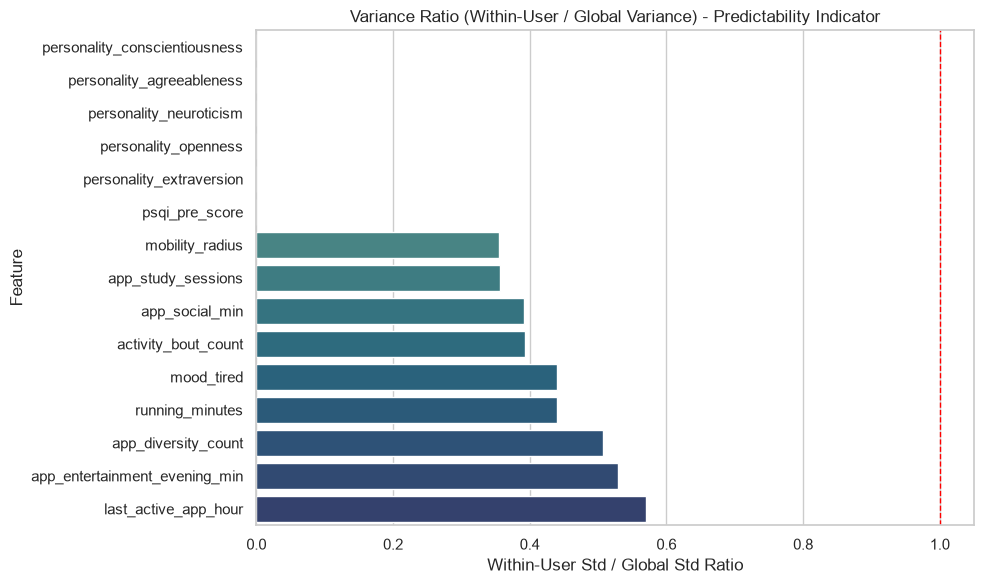

In [6]:
variance_records = []
for col in numeric_cols:
    if col == 'sleep_score':
        continue
    global_std = df[col].std()
    within_std = df.groupby('user_id')[col].std().mean()
    
    variance_records.append({
        'Feature': col,
        'Global Std': global_std,
        'Within-User Std': within_std,
        'Ratio (Within/Global)': within_std / global_std if global_std > 0 else np.nan
    })

var_df = pd.DataFrame(variance_records).dropna().sort_values(by='Ratio (Within/Global)')
print("Top 10 features with mostly between-user differences (low within-user variance ratio):")
print(var_df.head(10))
print("\nTop 10 features with mostly day-to-day within-user variation (high within-user variance ratio):")
print(var_df.tail(10))

# Plot top/bottom variance ratios
plt.figure(figsize=(10, 6))
sns.barplot(data=var_df.head(15), x='Ratio (Within/Global)', y='Feature', palette='crest')
plt.title("Variance Ratio (Within-User / Global Variance) - Predictability Indicator")
plt.xlabel("Within-User Std / Global Std Ratio")
plt.ylabel("Feature")
plt.axvline(x=1.0, color='red', linestyle='--', linewidth=1, label='Perfectly Equal')
plt.tight_layout()
try:
    plt.savefig('../implementation/eda_variance_ratios.png', dpi=150)
except Exception:
    plt.savefig('implementation/eda_variance_ratios.png', dpi=150)
plt.show()